Note: Training performance results can be viewed in the `zip` file included in this folder.

In [1]:
import os, gc
os.environ["KERAS_BACKEND"]               = "torch"
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
os.environ["PYTORCH_CUDA_ALLOC_CONF"]     = "expandable_segments:True"

import numpy as np
import pandas as pd
import torch
import keras
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, top_k_accuracy_score)

SEED = 42
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR    = Path("/home2/msds2026/fcapati/ml3_2026/Projects/Final_Project/data")
FRAMES_DIR  = DATA_DIR / "UCF50_frames"
DATASET_DIR = DATA_DIR / "UCF50"
PROJECT_DIR = Path("/home2/msds2026/fcapati/ml3_2026/Projects/Final_Project")

# ── Must match training config exactly ───────────────────────────────────────
IMG_HEIGHT      = 64
IMG_WIDTH       = 64
SEQUENCE_LENGTH = 16
BATCH_SIZE      = 4
NUM_CLASSES     = 50

CLASS_NAMES_SORTED = sorted([d.name for d in DATASET_DIR.iterdir() if d.is_dir()])
class_to_idx       = {cls: idx for idx, cls in enumerate(CLASS_NAMES_SORTED)}
idx_to_class       = {idx: cls for cls, idx in class_to_idx.items()}

print(f"✅ Keras backend : {keras.backend.backend()}")
print(f"✅ Device        : {DEVICE}")
print(f"✅ Classes       : {len(class_to_idx)}")
print(f"✅ Image size    : {IMG_HEIGHT}x{IMG_WIDTH}")
print(f"✅ Batch size    : {BATCH_SIZE}")

✅ Keras backend : torch
✅ Device        : cuda
✅ Classes       : 50
✅ Image size    : 64x64
✅ Batch size    : 4


# Test Dataset

In [2]:
class PreextractedDataset(Dataset):
    """
    Loads pre-extracted .npy frame arrays from disk.
    Resizes to IMG_HEIGHT x IMG_WIDTH to match training config exactly.
    """
    def __init__(self, frames_dir, split, class_to_idx):
        self.samples = []
        for class_dir in sorted((Path(frames_dir) / split).iterdir()):
            if not class_dir.is_dir():
                continue
            label = class_to_idx[class_dir.name]
            for npy_path in sorted(class_dir.glob("*.npy")):
                self.samples.append((str(npy_path), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        npy_path, label = self.samples[idx]
        frames = np.load(npy_path)                # (16, 112, 112, 3)

        # Resize to match training resolution (64x64)
        if frames.shape[1] != IMG_HEIGHT:
            frames = np.stack([
                cv2.resize(f, (IMG_WIDTH, IMG_HEIGHT)) for f in frames
            ])

        frames = torch.tensor(frames).permute(3, 0, 1, 2).float()  # (3, 16, 64, 64)
        return frames, torch.tensor(label, dtype=torch.long)


test_dataset = PreextractedDataset(FRAMES_DIR, "test", class_to_idx)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=False)

print(f"✅ Test set : {len(test_dataset):,} videos → {len(test_loader)} batches")

# ── Quick shape check ─────────────────────────────────────────────────────────
sample_frames, sample_labels = next(iter(test_loader))
print(f"   Batch shape : {sample_frames.shape}  → (B, C, T, H, W)")

✅ Test set : 698 videos → 175 batches
   Batch shape : torch.Size([4, 3, 16, 64, 64])  → (B, C, T, H, W)


In [4]:
# ── Check test split counts ───────────────────────────────────────────────────
from pathlib import Path

SPLIT_DIR  = DATA_DIR / "UCF50_split"
FRAMES_DIR = DATA_DIR / "UCF50_frames"

# Count original .avi files in test split
n_avi = len(list((SPLIT_DIR / "test").glob("*/*.avi")))

# Count extracted .npy files in test frames
n_npy = len(list((FRAMES_DIR / "test").glob("*/*.npy")))

print(f"Original .avi files in test split : {n_avi}")
print(f"Extracted .npy files in test split : {n_npy}")
print(f"Difference (skipped during extraction) : {n_avi - n_npy}")

Original .avi files in test split : 704
Extracted .npy files in test split : 698
Difference (skipped during extraction) : 6


In [5]:
skipped = []
for avi in sorted((SPLIT_DIR / "test").glob("*/*.avi")):
    npy = FRAMES_DIR / "test" / avi.parent.name / (avi.stem + ".npy")
    if not npy.exists():
        skipped.append(avi.name)

print(f"Skipped files ({len(skipped)}):")
for f in skipped:
    print(f"  {f}")

Skipped files (6):
  v_BaseballPitch_g09_c06.avi
  v_Basketball_g13_c04.avi
  v_GolfSwing_g11_c06.avi
  v_SoccerJuggling_g02_c03.avi
  v_SoccerJuggling_g05_c06.avi
  v_TennisSwing_g16_c04.avi


# Load Best Model

MobileNetV2 + LSTM was selected as the best model based on validation set performance (92.52% val accuracy), outperforming all scratch-built models by over 66 percentage points.

In [6]:
# ── Load best model ───────────────────────────────────────────────────────────
MODEL_PATH = PROJECT_DIR / "initial_models/best_MobileNetV2_LSTM.keras"

model = keras.models.load_model(str(MODEL_PATH))
print(f"✅ Model loaded : {MODEL_PATH.name}")
print(f"   Input shape  : {model.input_shape}")
print(f"   Output shape : {model.output_shape}")

✅ Model loaded : best_MobileNetV2_LSTM.keras
   Input shape  : (None, 16, 64, 64, 3)
   Output shape : (None, 50)


# Overall Test Accuracy

In [7]:
# ── Overall Test Accuracy via model.evaluate() ───────────────────────────────
# Collects all test frames and labels into numpy arrays first
print("Collecting test set...", flush=True)
test_frames_list, test_labels_list = [], []

for frames, labels in test_loader:
    test_frames_list.append(frames.permute(0, 2, 3, 4, 1).numpy())
    test_labels_list.append(labels.numpy())

test_frames_np = np.concatenate(test_frames_list, axis=0)
test_labels_np = np.concatenate(test_labels_list, axis=0)

print(f"Test frames shape : {test_frames_np.shape}")
print(f"Test labels shape : {test_labels_np.shape}")

print("\nEvaluating...", flush=True)
test_loss, test_acc = model.evaluate(
    test_frames_np, test_labels_np,
    batch_size=BATCH_SIZE, verbose=1
)

print(f"\n{'='*45}")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"{'='*45}")

Test frames shape : (698, 16, 64, 64, 3)
Test labels shape : (698,)

Evaluating...


/home/msds2026/fcapati/.conda/envs/msds2026-ml3-cnn/lib/python3.11/site-packages/keras/src/backend/torch/rnn.py:651: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  outputs, (h_n, c_n) = torch._VF.lstm(


175/175 ━━━━━━━━━━━━━━━━━━━━ 279s 2s/step - accuracy: 0.8725 - loss: 0.6601

  Test Loss     : 0.6601
  Test Accuracy : 0.8725  (87.25%)


In [15]:
# ── Evaluate All Models on Test Set ──────────────────────────────────────────
import gc

# ── Model paths ───────────────────────────────────────────────────────────────
# Update paths to match where your .keras files are saved
model_files = {
    "M0: CNN + RNN (Baseline)"          : PROJECT_DIR / "initial_models/best_CNN_VanillaRNN.keras",
    "M0_Improved: CNN + RNN (32→64→128)": PROJECT_DIR / "initial_models/best_M0_CNNImproved_VanillaRNN.keras",
    "M1: CNN + GRU"                     : PROJECT_DIR / "initial_models/best_CNN_GRU.keras",
    "M1_Improved: CNN + GRU (32→64→128)": PROJECT_DIR / "initial_models/best_M1_CNNImproved_GRU.keras",
    "M2: CNN + LSTM"                    : PROJECT_DIR / "initial_models/best_CNN_LSTM.keras",
    "M2_Improved: CNN + LSTM (32→64→128)": PROJECT_DIR / "initial_models/best_M2_CNNImproved_LSTM.keras",
    "M3: MobileNetV2 + LSTM"            : PROJECT_DIR / "initial_models/best_MobileNetV2_LSTM.keras",
}

# ── Collect test set once ─────────────────────────────────────────────────────
print("Collecting test set...", flush=True)
test_frames_list, test_labels_list = [], []
for frames, labels in test_loader:
    test_frames_list.append(frames.permute(0, 2, 3, 4, 1).numpy())
    test_labels_list.append(labels.numpy())

test_frames_np = np.concatenate(test_frames_list, axis=0)
test_labels_np = np.concatenate(test_labels_list, axis=0)
print(f"✅ Test frames : {test_frames_np.shape}")
print(f"✅ Test labels : {test_labels_np.shape}")

# ── Evaluate each model ───────────────────────────────────────────────────────
results = []

for model_name, model_path in model_files.items():
    if not model_path.exists():
        print(f"⚠️  Not found: {model_path.name} — skipping")
        results.append({"Model": model_name, "Test Loss": None, "Test Acc": None})
        continue

    print(f"\n{'='*55}", flush=True)
    print(f"Evaluating: {model_name}", flush=True)

    gc.collect()
    torch.cuda.empty_cache()

    model = keras.models.load_model(str(model_path))
    test_loss, test_acc = model.evaluate(
        test_frames_np, test_labels_np,
        batch_size=BATCH_SIZE, verbose=1
    )

    results.append({
        "Model"    : model_name,
        "Test Loss": round(test_loss, 4),
        "Test Acc" : round(test_acc,  4),
    })

    print(f"  Test Loss : {test_loss:.4f}", flush=True)
    print(f"  Test Acc  : {test_acc:.4f}  ({test_acc*100:.2f}%)", flush=True)

    del model
    gc.collect()
    torch.cuda.empty_cache()

# ── Summary table ─────────────────────────────────────────────────────────────
results_df = (pd.DataFrame(results)
                .sort_values("Test Acc", ascending=False)
                .reset_index(drop=True))

print("\n=== Test Set Accuracy — All Models ===")
display(results_df)

✅ Test frames : (698, 16, 64, 64, 3)
✅ Test labels : (698,)

Evaluating: M0: CNN + RNN (Baseline)
175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.2708 - loss: 2.5487
  Test Loss : 2.5487
  Test Acc  : 0.2708  (27.08%)

Evaluating: M0_Improved: CNN + RNN (32→64→128)
175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.3381 - loss: 2.3193
  Test Loss : 2.3193
  Test Acc  : 0.3381  (33.81%)

Evaluating: M1: CNN + GRU
  5/175 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.1133 - loss: 2.6759

/home/msds2026/fcapati/.conda/envs/msds2026-ml3-cnn/lib/python3.11/site-packages/keras/src/backend/torch/rnn.py:853: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  outputs, h_n = torch._VF.gru(


175/175 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.2106 - loss: 2.8661
  Test Loss : 2.8661
  Test Acc  : 0.2106  (21.06%)

Evaluating: M1_Improved: CNN + GRU (32→64→128)
175/175 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.2980 - loss: 2.5357
  Test Loss : 2.5357
  Test Acc  : 0.2980  (29.80%)

Evaluating: M2: CNN + LSTM
  5/175 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.4908 - loss: 2.4934

/home/msds2026/fcapati/.conda/envs/msds2026-ml3-cnn/lib/python3.11/site-packages/keras/src/backend/torch/rnn.py:651: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  outputs, (h_n, c_n) = torch._VF.lstm(


175/175 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.2607 - loss: 2.7217
  Test Loss : 2.7217
  Test Acc  : 0.2607  (26.07%)

Evaluating: M2_Improved: CNN + LSTM (32→64→128)
175/175 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.3181 - loss: 2.4018
  Test Loss : 2.4018
  Test Acc  : 0.3181  (31.81%)

Evaluating: M3: MobileNetV2 + LSTM
175/175 ━━━━━━━━━━━━━━━━━━━━ 275s 2s/step - accuracy: 0.8725 - loss: 0.6601
  Test Loss : 0.6601
  Test Acc  : 0.8725  (87.25%)

=== Test Set Accuracy — All Models ===


,Model,Test Loss,Test Acc
0,M3: MobileNetV2 + LSTM,0.6601,0.8725
1,M0_Improved: CNN + RNN (32→64→128),2.3193,0.3381
2,M2_Improved: CNN + LSTM (32→64→128),2.4018,0.3181
3,M1_Improved: CNN + GRU (32→64→128),2.5357,0.2980
4,M0: CNN + RNN (Baseline),2.5487,0.2708
5,M2: CNN + LSTM,2.7217,0.2607
6,M1: CNN + GRU,2.8661,0.2106


# Inference for Detailed Metrics

In [8]:
# ── Run inference for detailed metrics ────────────────────────────────────────
print("Running inference for per-class metrics...", flush=True)

all_probs  = model.predict(test_frames_np, batch_size=BATCH_SIZE, verbose=1)
all_preds  = np.argmax(all_probs, axis=1)
all_labels = test_labels_np

print(f"\n✅ Inference complete : {len(all_labels):,} samples")

Running inference for per-class metrics...
175/175 ━━━━━━━━━━━━━━━━━━━━ 269s 2s/step

✅ Inference complete : 698 samples


# Top-1 and Top-5 Accuracy

In [9]:
# ── Top-1 and Top-5 Accuracy ─────────────────────────────────────────────────
top1 = accuracy_score(all_labels, all_preds)
top5 = top_k_accuracy_score(all_labels, all_probs, k=5)

print(f"{'='*45}")
print(f"  Top-1 Accuracy : {top1:.4f}  ({top1*100:.2f}%)")
print(f"  Top-5 Accuracy : {top5:.4f}  ({top5*100:.2f}%)")
print(f"{'='*45}")

  Top-1 Accuracy : 0.8725  (87.25%)
  Top-5 Accuracy : 0.9670  (96.70%)


# Summary Table

In [10]:
# ── Summary Table ────────────────────────────────────────────────────────────
report_dict = classification_report(
    all_labels, all_preds,
    target_names=CLASS_NAMES_SORTED,
    output_dict=True
)

summary = pd.DataFrame({
    "Metric": [
        "Top-1 Accuracy",
        "Top-5 Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1",
        "Total Test Samples",
        "Classes",
    ],
    "Value": [
        f"{top1*100:.2f}%",
        f"{top5*100:.2f}%",
        f"{report_dict['macro avg']['precision']*100:.2f}%",
        f"{report_dict['macro avg']['recall']*100:.2f}%",
        f"{report_dict['macro avg']['f1-score']*100:.2f}%",
        f"{report_dict['weighted avg']['f1-score']*100:.2f}%",
        str(len(all_labels)),
        str(NUM_CLASSES),
    ]
})

print("=" * 45)
print("   Model Performance Summary")
print("   MobileNetV2 + LSTM | Test Set")
print("=" * 45)
display(summary)

   Model Performance Summary
   MobileNetV2 + LSTM | Test Set


,Metric,Value
0,Top-1 Accuracy,87.25%
1,Top-5 Accuracy,96.70%
2,Macro Precision,88.05%
3,Macro Recall,86.77%
4,Macro F1,86.86%
5,Weighted F1,87.21%
6,Total Test Samples,698
7,Classes,50


# Per-Class Classification Report

In [11]:
# ── Per-class Classification Report ──────────────────────────────────────────
print(classification_report(
    all_labels, all_preds,
    target_names=CLASS_NAMES_SORTED,
    digits=4
))

# ── Best and worst classes ────────────────────────────────────────────────────
report_df = pd.DataFrame(report_dict).T.round(4)
class_f1  = report_df.loc[CLASS_NAMES_SORTED, "f1-score"].sort_values(ascending=False)

print("\n Top 10 Best Performing Classes:")
print(class_f1.head(10).to_string())

print("\n  Top 10 Worst Performing Classes:")
print(class_f1.tail(10).to_string())

                    precision    recall  f1-score   support

     BaseballPitch     0.9333    1.0000    0.9655        14
        Basketball     0.8462    0.7857    0.8148        14
        BenchPress     0.8889    1.0000    0.9412        16
            Biking     0.7368    0.9333    0.8235        15
         Billiards     1.0000    1.0000    1.0000        15
      BreastStroke     1.0000    0.7273    0.8421        11
      CleanAndJerk     0.9000    0.7500    0.8182        12
            Diving     0.8333    0.9375    0.8824        16
          Drumming     1.0000    0.9412    0.9697        17
           Fencing     1.0000    1.0000    1.0000        12
         GolfSwing     1.0000    0.7857    0.8800        14
          HighJump     0.9091    0.7692    0.8333        13
         HorseRace     0.9167    0.7857    0.8462        14
       HorseRiding     0.9130    1.0000    0.9545        21
          HulaHoop     1.0000    0.7692    0.8696        13
      JavelinThrow     0.9231    0.9231

# Confusion Matrix

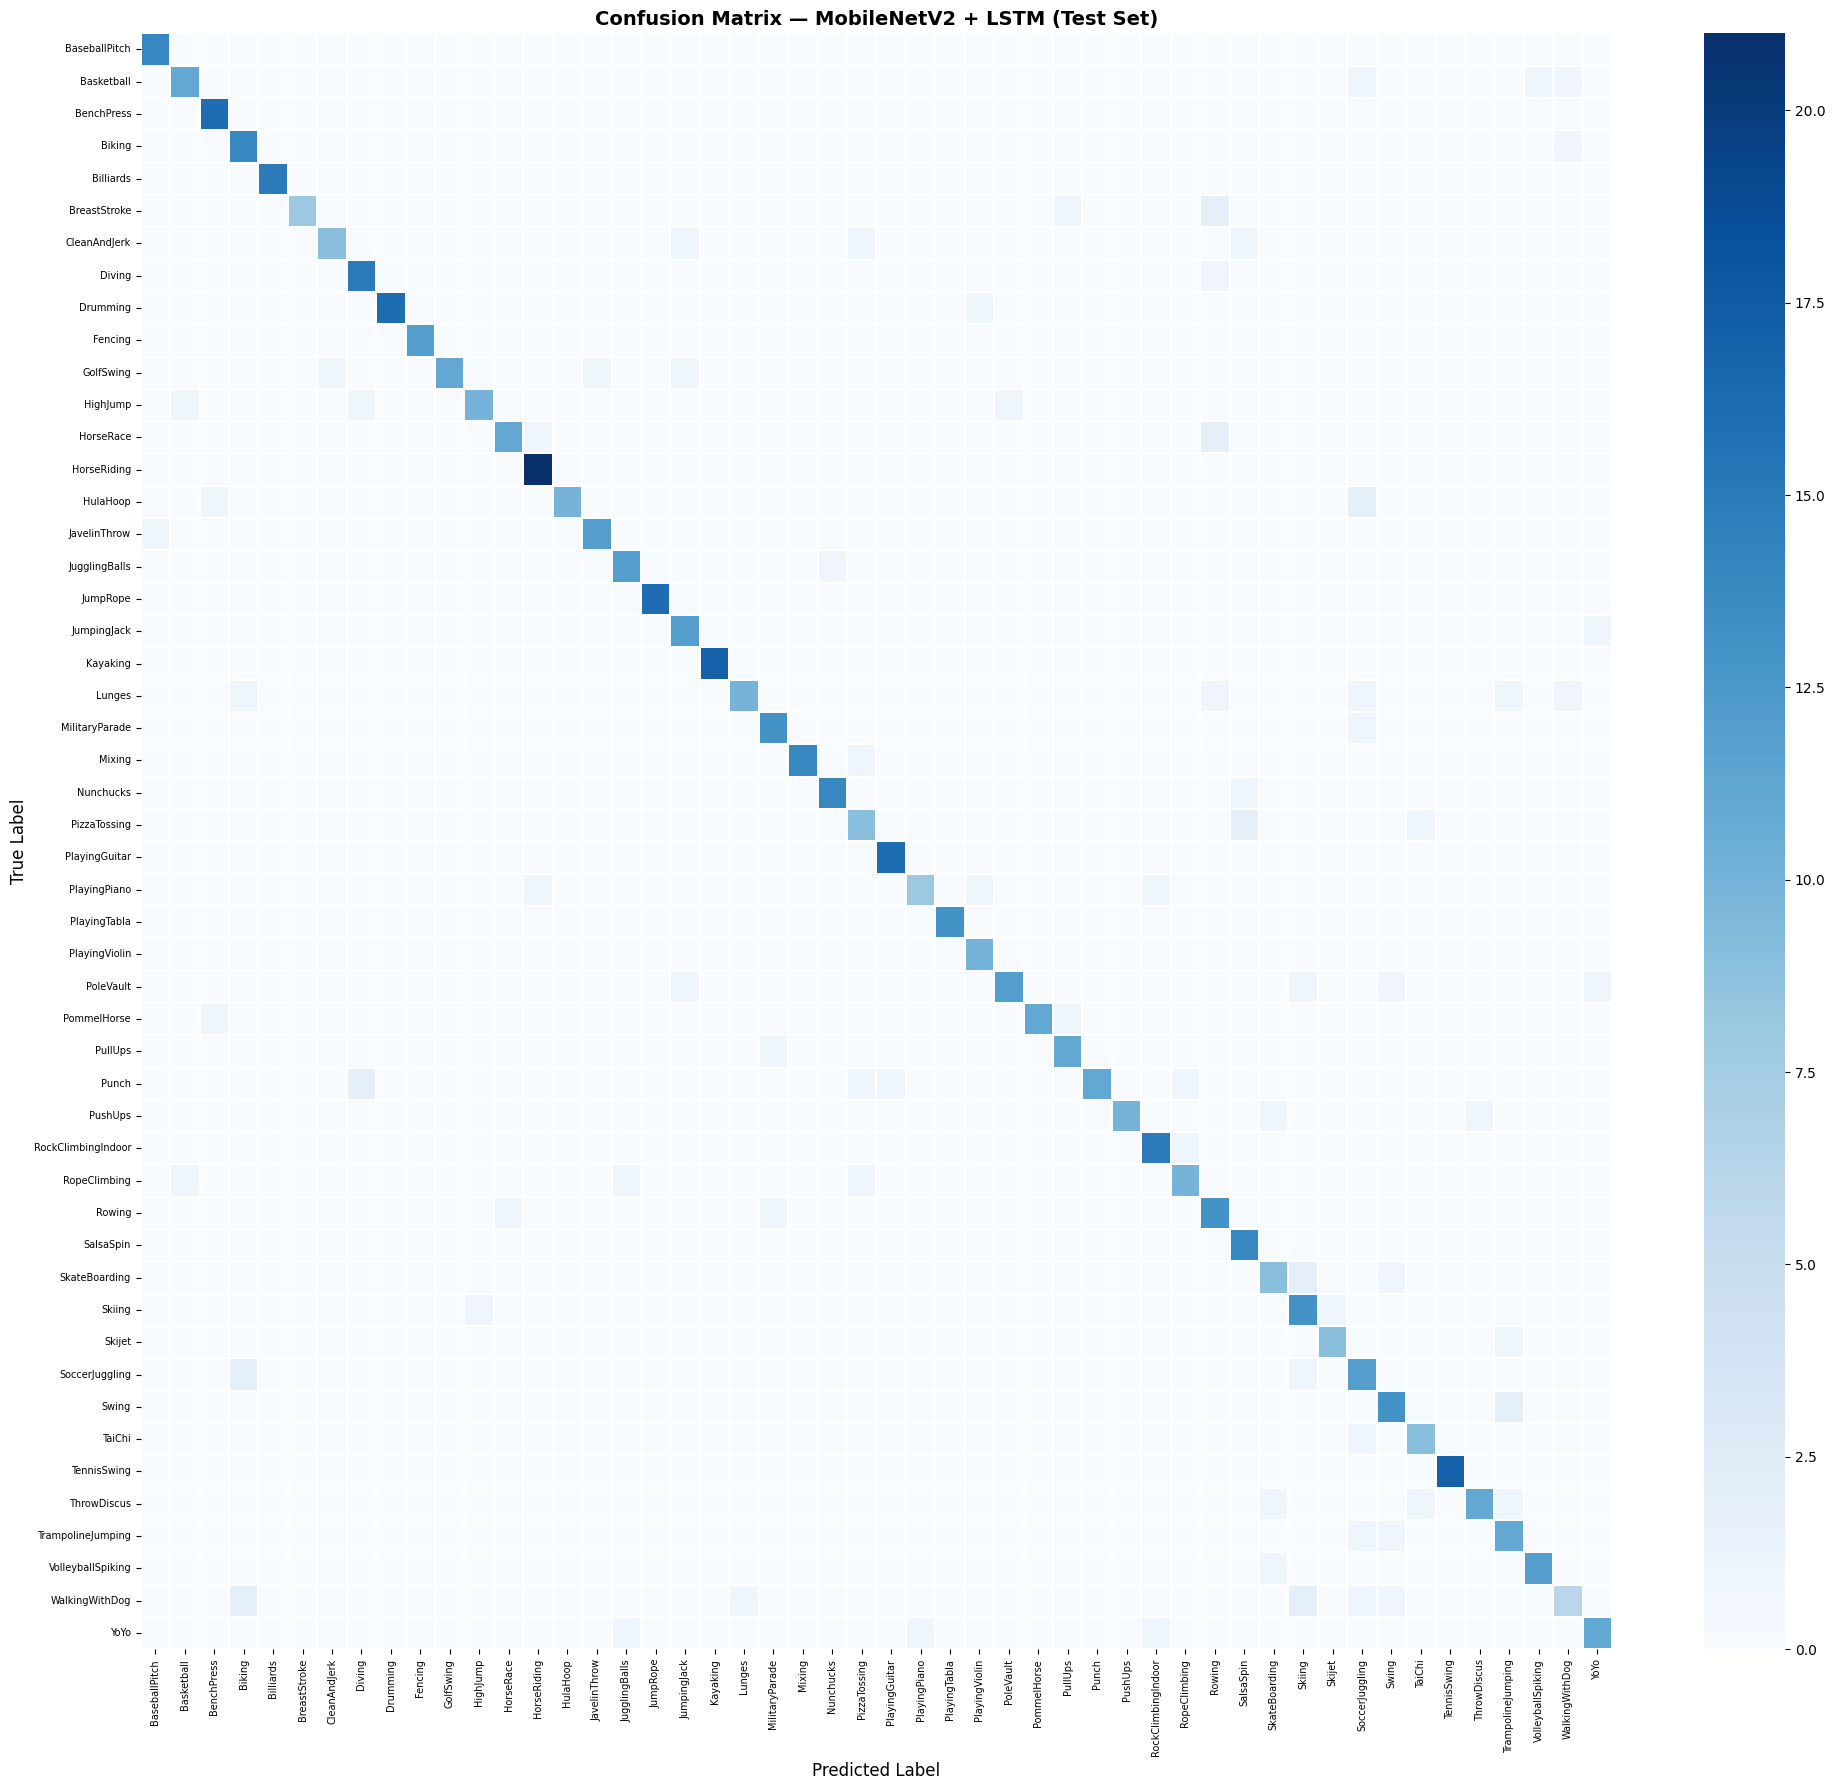

Saved: confusion_matrix.png


In [12]:
# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(20, 18))
sns.heatmap(
    cm,
    annot       = False,
    fmt         = "d",
    cmap        = "Blues",
    xticklabels = CLASS_NAMES_SORTED,
    yticklabels = CLASS_NAMES_SORTED,
    linewidths  = 0.3,
    ax          = ax
)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label",      fontsize=12)
ax.set_title("Confusion Matrix — MobileNetV2 + LSTM (Test Set)",
             fontsize=14, fontweight="bold")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Saved: confusion_matrix.png")

# Per-Class F1 Bar Chart

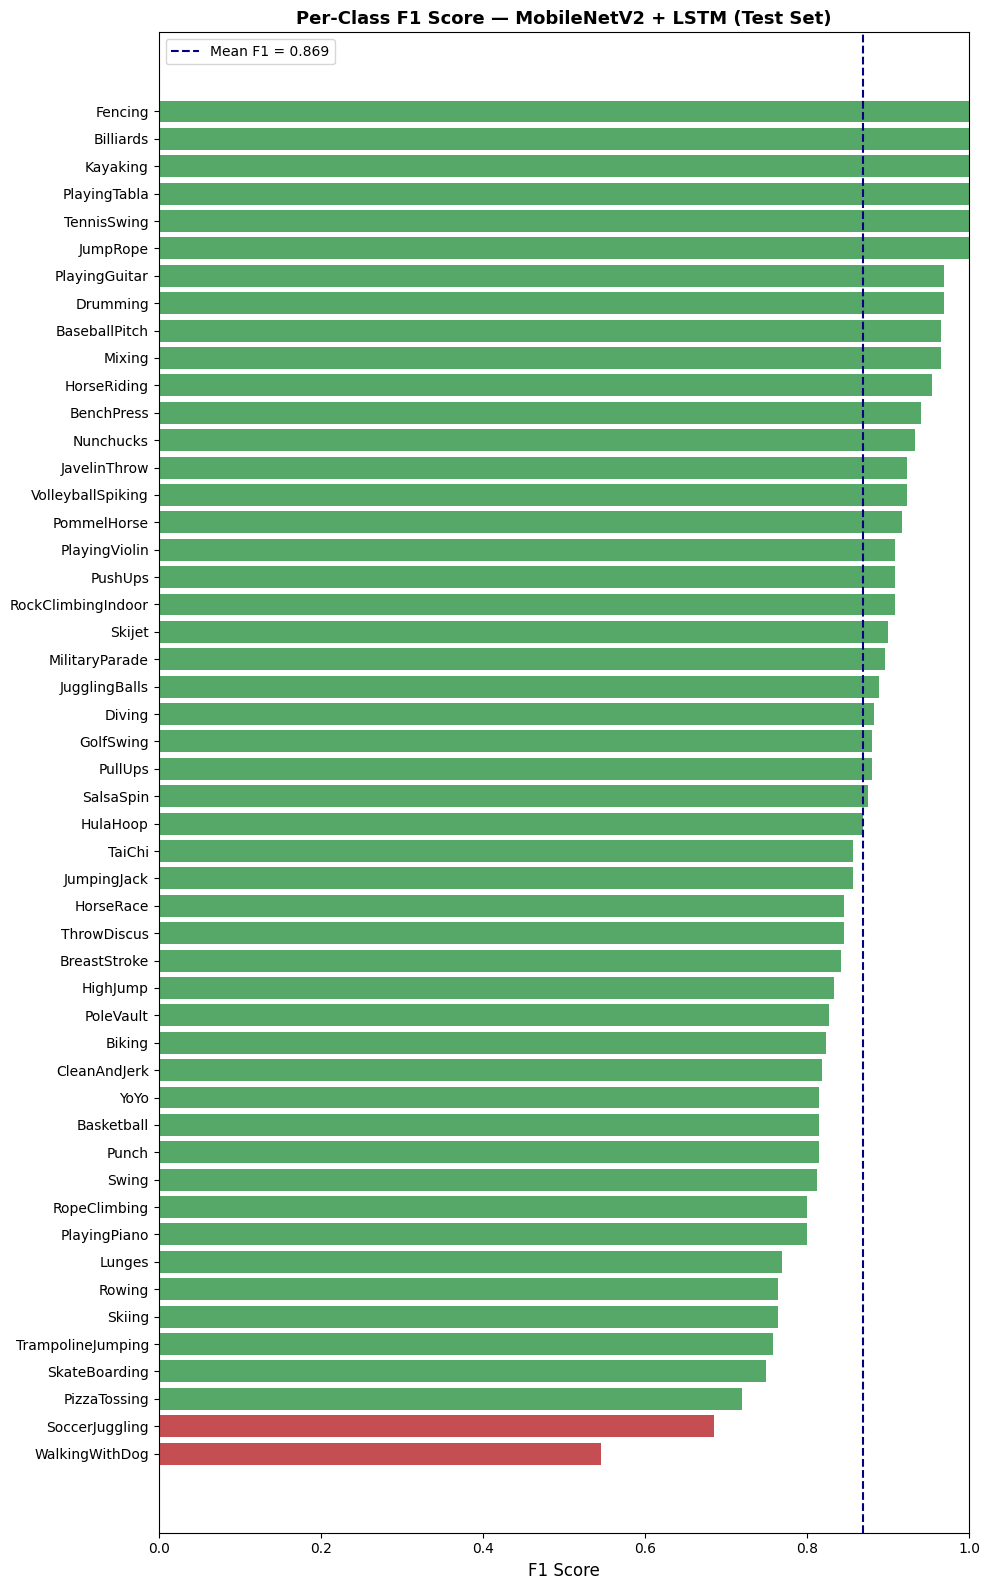

Saved: per_class_f1.png


In [13]:
# ── Per-class F1 bar chart ───────────────────────────────────────────────────
class_f1_sorted = class_f1.sort_values(ascending=True)
colors = ["#C44E52" if v < 0.7 else "#55A868" for v in class_f1_sorted]

fig, ax = plt.subplots(figsize=(10, 16))
ax.barh(class_f1_sorted.index, class_f1_sorted.values, color=colors)
ax.axvline(class_f1_sorted.mean(), color="navy", linestyle="--",
           linewidth=1.5, label=f"Mean F1 = {class_f1_sorted.mean():.3f}")
ax.set_xlabel("F1 Score", fontsize=12)
ax.set_title("Per-Class F1 Score — MobileNetV2 + LSTM (Test Set)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig("per_class_f1.png", dpi=150)
plt.show()
print("Saved: per_class_f1.png")

# Most Confused Class Pairs

In [14]:
# ── Most confused class pairs ─────────────────────────────────────────────────
confused_pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm[i, j] > 0:
            confused_pairs.append({
                "True Class"  : CLASS_NAMES_SORTED[i],
                "Predicted As": CLASS_NAMES_SORTED[j],
                "Count"       : cm[i, j],
            })

confused_df = (pd.DataFrame(confused_pairs)
                 .sort_values("Count", ascending=False)
                 .head(15)
                 .reset_index(drop=True))

print("=== Top 15 Most Confused Class Pairs ===")
display(confused_df)

=== Top 15 Most Confused Class Pairs ===


,True Class,Predicted As,Count
0,BreastStroke,Rowing,2
1,WalkingWithDog,Biking,2
2,Swing,TrampolineJumping,2
3,PizzaTossing,SalsaSpin,2
4,Punch,Diving,2
5,HulaHoop,SoccerJuggling,2
6,WalkingWithDog,Skiing,2
7,SoccerJuggling,Biking,2
8,SkateBoarding,Skiing,2
9,HorseRace,Rowing,2


# Sample Prediction

In [59]:
# ── Reload model if not already loaded ───────────────────────────────────────
import os, gc
os.environ["KERAS_BACKEND"]               = "torch"
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import cv2
import numpy as np
import matplotlib.pyplot as plt
import keras
import torch
from pathlib import Path

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR    = Path("/home2/msds2026/fcapati/ml3_2026/Projects/Final_Project/data")
SPLIT_DIR   = DATA_DIR / "UCF50_split"
DATASET_DIR = DATA_DIR / "UCF50"
PROJECT_DIR = Path("/home2/msds2026/fcapati/ml3_2026/Projects/Final_Project")

IMG_HEIGHT      = 64
IMG_WIDTH       = 64
SEQUENCE_LENGTH = 16

CLASS_NAMES_SORTED = sorted([d.name for d in DATASET_DIR.iterdir() if d.is_dir()])
class_to_idx       = {cls: idx for idx, cls in enumerate(CLASS_NAMES_SORTED)}
idx_to_class       = {idx: cls for cls, idx in class_to_idx.items()}

# Load model
MODEL_PATH = PROJECT_DIR / "initial_models/best_MobileNetV2_LSTM.keras"
model      = keras.models.load_model(str(MODEL_PATH))
print(f"✅ Model loaded : {MODEL_PATH.name}")


# ── Clip loading helpers ──────────────────────────────────────────────────────
def load_clip_for_model(video_path, sequence_length=SEQUENCE_LENGTH,
                        img_height=IMG_HEIGHT, img_width=IMG_WIDTH):
    """Load clip preprocessed for model input: (1, 16, 64, 64, 3)."""
    cap          = cv2.VideoCapture(str(video_path))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices      = np.linspace(0, total_frames - 1, sequence_length, dtype=int)

    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frame = cv2.resize(frame, (img_width, img_height))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = frame / 255.0
            frames.append(frame)
    cap.release()

    # ── Pad with last frame if fewer than sequence_length frames extracted ────
    while len(frames) < sequence_length:
        frames.append(frames[-1])  # repeat last frame

    frames_np = np.array(frames[:sequence_length], dtype=np.float32)
    return np.expand_dims(frames_np, axis=0)   # (1, 16, 64, 64, 3)

def load_clip_for_display(video_path, n_frames=4):
    """Load n_frames evenly spaced frames at original resolution for display."""
    cap          = cv2.VideoCapture(str(video_path))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices      = np.linspace(0, total_frames - 1, n_frames, dtype=int)
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()
    return frames

print("✅ Clip loading functions defined")
print(f"✅ Classes       : {len(class_to_idx)}")

✅ Model loaded : best_MobileNetV2_LSTM.keras
✅ Clip loading functions defined
✅ Classes       : 50


/tmp/ipykernel_256784/3379118326.py:51: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256784/3379118326.py:52: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("sample_prediction.png", dpi=150, bbox_inches="tight")


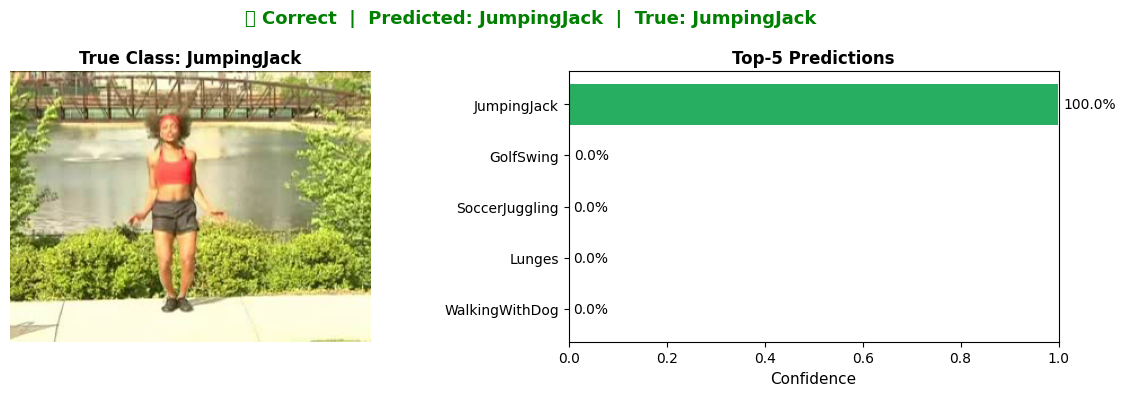

Video      : v_JumpingJack_g14_c01.avi
True class : JumpingJack
Predicted  : JumpingJack  (100.0% confidence)
Result     : ✅ Correct

Top-5 predictions:
  1. JumpingJack               100.0%  ← TRUE
  2. GolfSwing                 0.0%  
  3. SoccerJuggling            0.0%  
  4. Lunges                    0.0%  
  5. WalkingWithDog            0.0%  


In [46]:
# ── Browse available test videos for a class (uncomment to use) ──────────────
# target_class = "Diving"
# available = sorted((SPLIT_DIR / "test" / target_class).glob("*.avi"))
# for v in available:
#     print(v.name)

# ── Specify your video here ───────────────────────────────────────────────────
# Format: SPLIT_DIR / "test" / "<ClassName>" / "<filename>.avi"
sample_video = SPLIT_DIR / "test" / "JumpingJack" / "v_JumpingJack_g14_c01.avi"
# sample_video = SPLIT_DIR / "test" / "BaseballPitch" / "v_BaseballPitch_g05_c01.avi"
# sample_video = SPLIT_DIR / "test" / "PlayingViolin" / "v_PlayingViolin_g24_c03.avi"


# ── Run prediction ────────────────────────────────────────────────────────────
true_class = sample_video.parent.name
frames_np  = load_clip_for_model(sample_video)
probs      = model.predict(frames_np, verbose=0)[0]   # (50,)

top5_idx   = np.argsort(probs)[::-1][:5]
top5_cls   = [idx_to_class[i] for i in top5_idx]
top5_prob  = [probs[i]        for i in top5_idx]
pred_class = top5_cls[0]
correct    = pred_class == true_class

# ── Display ───────────────────────────────────────────────────────────────────
display_frames = load_clip_for_display(sample_video, n_frames=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(display_frames[0])
axes[0].set_title(f"True Class: {true_class}", fontsize=12, fontweight="bold")
axes[0].axis("off")

bar_colors = ["#27AE60" if cls == true_class else
              "#C44E52" if i == 0 else "#95A5A6"
              for i, cls in enumerate(top5_cls)]

axes[1].barh(top5_cls[::-1], top5_prob[::-1], color=bar_colors[::-1])
axes[1].set_xlabel("Confidence", fontsize=11)
axes[1].set_title("Top-5 Predictions", fontsize=12, fontweight="bold")
axes[1].set_xlim(0, 1)

for i, (cls, prob) in enumerate(zip(top5_cls[::-1], top5_prob[::-1])):
    axes[1].text(prob + 0.01, i, f"{prob:.1%}", va="center", fontsize=10)

status = "✅ Correct" if correct else "❌ Incorrect"
color  = "green"     if correct else "red"
plt.suptitle(f"{status}  |  Predicted: {pred_class}  |  True: {true_class}",
             fontsize=13, fontweight="bold", color=color)

plt.tight_layout()
plt.savefig("sample_prediction.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Video      : {sample_video.name}")
print(f"True class : {true_class}")
print(f"Predicted  : {pred_class}  ({probs[top5_idx[0]]:.1%} confidence)")
print(f"Result     : {status}")
print(f"\nTop-5 predictions:")
for i, (cls, prob) in enumerate(zip(top5_cls, top5_prob)):
    marker = "← TRUE" if cls == true_class else ""
    print(f"  {i+1}. {cls:25s} {prob:.1%}  {marker}")

In [24]:
# ── Check if the video file exists ───────────────────────────────────────────
sample_video = SPLIT_DIR / "test" / "Diving" / "v_Diving_g03_c01.avi"
print(f"File exists : {sample_video.exists()}")
print(f"Full path   : {sample_video}")

File exists : False
Full path   : /home2/msds2026/fcapati/ml3_2026/Projects/Final_Project/data/UCF50_split/test/Diving/v_Diving_g03_c01.avi


In [39]:
# ── Browse available Diving test videos ──────────────────────────────────────
available = sorted((SPLIT_DIR / "test" / "JumpingJack").glob("*.avi"))
print(f"\nAvailable test videos ({len(available)} total):")
for v in available[:10]:
    print(f"  {v.name}")


Available test videos (13 total):
  v_JumpingJack_g01_c04.avi
  v_JumpingJack_g03_c03.avi
  v_JumpingJack_g03_c04.avi
  v_JumpingJack_g04_c03.avi
  v_JumpingJack_g06_c04.avi
  v_JumpingJack_g06_c07.avi
  v_JumpingJack_g07_c04.avi
  v_JumpingJack_g14_c01.avi
  v_JumpingJack_g17_c01.avi
  v_JumpingJack_g18_c02.avi


## Additional Sample Predictions: Own videos

/tmp/ipykernel_256784/4068387502.py:49: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_256784/4068387502.py:50: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("sample_prediction.png", dpi=150, bbox_inches="tight")


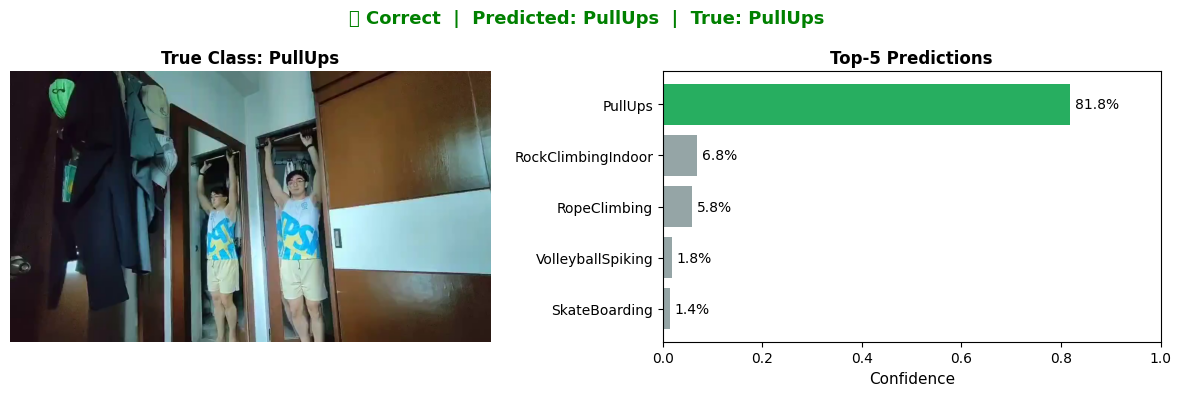

Video      : hakee_pullups_v2.avi
True class : PullUps
Predicted  : PullUps  (81.8% confidence)
Result     : ✅ Correct

Top-5 predictions:
  1. PullUps                   81.8%  ← TRUE
  2. RockClimbingIndoor        6.8%  
  3. RopeClimbing              5.8%  
  4. VolleyballSpiking         1.8%  
  5. SkateBoarding             1.4%  


In [70]:
# ── Browse available test videos for a class (uncomment to use) ──────────────
# target_class = "Diving"
# available = sorted((SPLIT_DIR / "test" / target_class).glob("*.avi"))
# for v in available:
#     print(v.name)

# ── Specify your video here ───────────────────────────────────────────────────
# Format: SPLIT_DIR / "test" / "<ClassName>" / "<filename>.avi"
sample_video = Path("/home2/msds2026/fcapati/ml3_2026/Projects/Final_Project/data/Fresh_Samples/hakee_pullups_v2.avi")
true_class   = "PullUps"

# ── Run prediction ────────────────────────────────────────────────────────────
# true_class = sample_video.parent.name
frames_np  = load_clip_for_model(sample_video)
probs      = model.predict(frames_np, verbose=0)[0]   # (50,)

top5_idx   = np.argsort(probs)[::-1][:5]
top5_cls   = [idx_to_class[i] for i in top5_idx]
top5_prob  = [probs[i]        for i in top5_idx]
pred_class = top5_cls[0]
correct    = pred_class == true_class

# ── Display ───────────────────────────────────────────────────────────────────
display_frames = load_clip_for_display(sample_video, n_frames=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(display_frames[0])
axes[0].set_title(f"True Class: {true_class}", fontsize=12, fontweight="bold")
axes[0].axis("off")

bar_colors = ["#27AE60" if cls == true_class else
              "#C44E52" if i == 0 else "#95A5A6"
              for i, cls in enumerate(top5_cls)]

axes[1].barh(top5_cls[::-1], top5_prob[::-1], color=bar_colors[::-1])
axes[1].set_xlabel("Confidence", fontsize=11)
axes[1].set_title("Top-5 Predictions", fontsize=12, fontweight="bold")
axes[1].set_xlim(0, 1)

for i, (cls, prob) in enumerate(zip(top5_cls[::-1], top5_prob[::-1])):
    axes[1].text(prob + 0.01, i, f"{prob:.1%}", va="center", fontsize=10)

status = "✅ Correct" if correct else "❌ Incorrect"
color  = "green"     if correct else "red"
plt.suptitle(f"{status}  |  Predicted: {pred_class}  |  True: {true_class}",
             fontsize=13, fontweight="bold", color=color)

plt.tight_layout()
plt.savefig("sample_prediction.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Video      : {sample_video.name}")
print(f"True class : {true_class}")
print(f"Predicted  : {pred_class}  ({probs[top5_idx[0]]:.1%} confidence)")
print(f"Result     : {status}")
print(f"\nTop-5 predictions:")
for i, (cls, prob) in enumerate(zip(top5_cls, top5_prob)):
    marker = "← TRUE" if cls == true_class else ""
    print(f"  {i+1}. {cls:25s} {prob:.1%}  {marker}")